In [ ]:
import os
import yaml
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from collections import Counter
import random

BASE = Path(r"C:\Projects\RoadGuard-AI\data\raw")
CLASSES = ["D00", "D10", "D20", "D40", "D50"]
COLORS  = ["#E74C3C", "#3498DB", "#2ECC71", "#F39C12", "#9B59B6"]

## Count class's element & statistics 

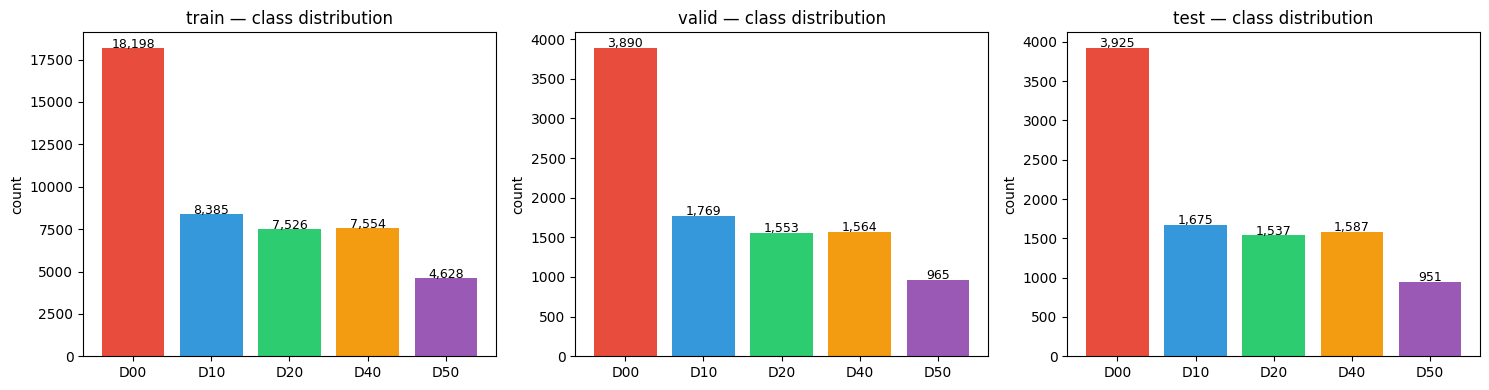

In [24]:
def count_classes(split):
    labels_dir = BASE / split / "labels"
    counter = Counter()
    for f in labels_dir.glob("*.txt"):
        for line in f.read_text().strip().splitlines():
            if line:
                cls = int(line.split()[0])
                counter[cls] += 1
    return counter

splits = ["train", "valid", "test"]
counts = {s: count_classes(s) for s in splits}

# رسم التوزيع
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, split in zip(axes, splits):
    vals = [counts[split].get(i, 0) for i in range(5)]
    bars = ax.bar(CLASSES, vals, color=COLORS)
    ax.set_title(f"{split} — class distribution")
    ax.set_ylabel("count")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 10,
                f"{val:,}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(r"C:\Projects\RoadGuard-AI\results\visualizations\class_distribution.png", dpi=150)
plt.show()

In [ ]:
counts

{'train': Counter({0: 18198, 1: 8385, 3: 7554, 2: 7526, 4: 4628}),
 'valid': Counter({0: 3890, 1: 1769, 3: 1564, 2: 1553, 4: 965}),
 'test': Counter({0: 3925, 1: 1675, 3: 1587, 2: 1537, 4: 951})}

## Visualization 

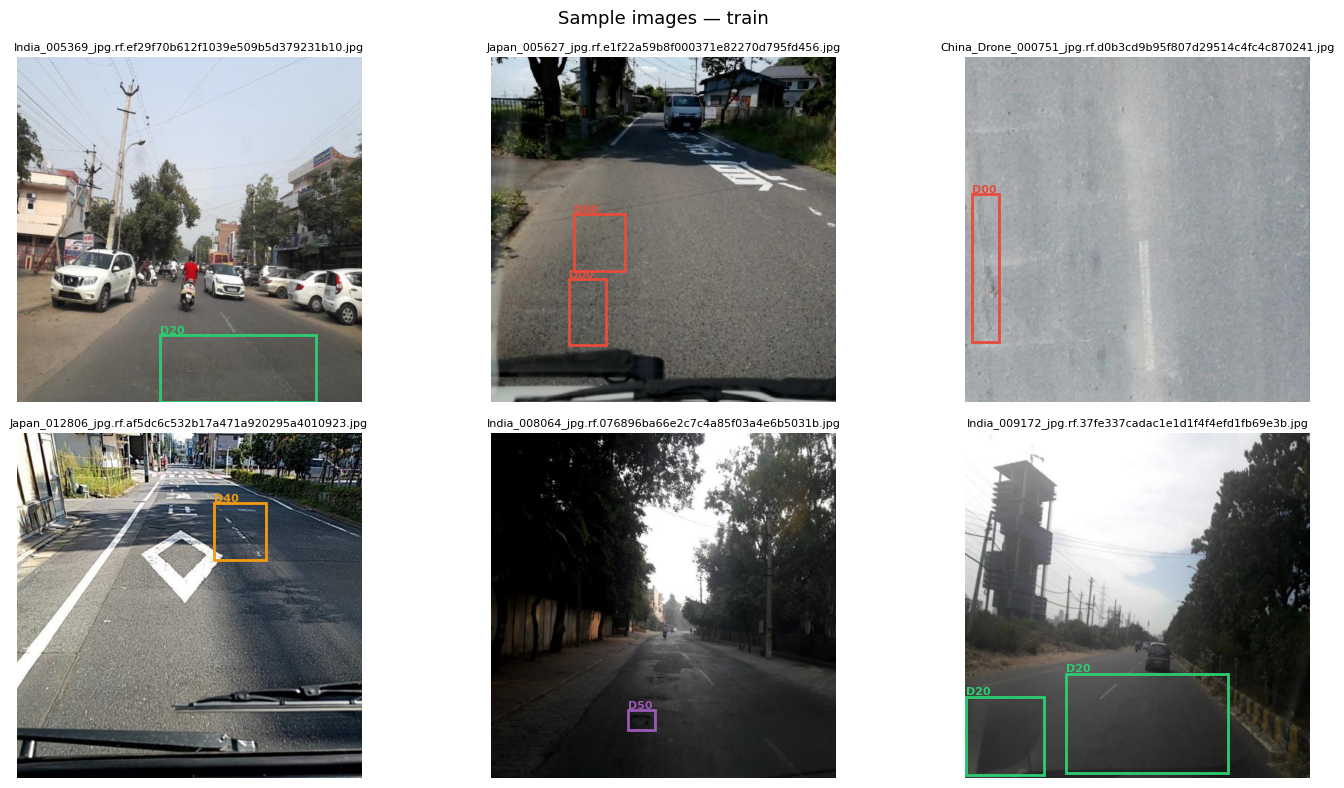

In [30]:
def show_samples(split, n=6):
    img_dir = BASE / split / "images"
    lbl_dir = BASE / split / "labels"
    imgs = random.sample(list(img_dir.glob("*.jpg")), k=n)

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()

    # display images 
    for ax, img_path in zip(axes, imgs):
        img = cv2.imread(str(img_path))                  # Read image in BGR format
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)       # Convert to RGB for matplotlib
        ax.imshow(img)
        
        # Get image dimensions
        h, w = img.shape[:2]
        lbl_path = lbl_dir / (img_path.stem + ".txt")
        if lbl_path.exists():
            for line in lbl_path.read_text().strip().splitlines():
                if not line: continue
                cls, cx, cy, bw, bh = map(float, line.split())
                cls = int(cls)
                x = (cx - bw/2) * w
                y = (cy - bh/2) * h
                rect = patches.Rectangle(
                    (x, y), bw*w, bh*h,
                    linewidth=2,
                    edgecolor=COLORS[cls],
                    facecolor="none"
                )
                ax.add_patch(rect)
                ax.text(x, y-4, CLASSES[cls],
                        color=COLORS[cls],
                        fontsize=8, fontweight="bold")

        ax.axis("off")
        ax.set_title(img_path.name, fontsize=8)

    plt.suptitle(f"Sample images — {split}", fontsize=13)
    plt.tight_layout()
    plt.savefig(rf"C:\Projects\RoadGuard-AI\results\visualizations\samples_{split}.png", dpi=150)
    plt.show()

show_samples("train")

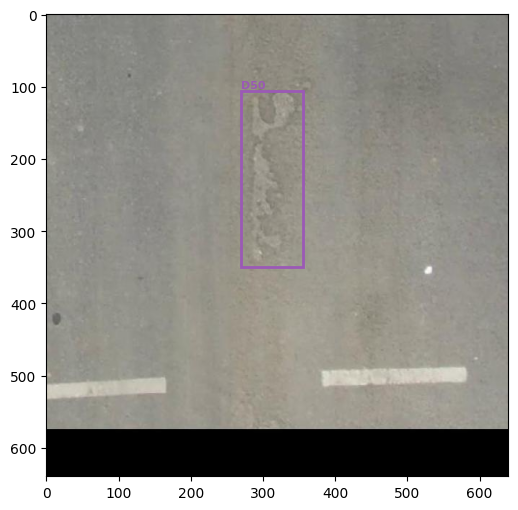

In [31]:
img_path = BASE / "train" / "images" / ("China_Drone_000048_jpg.rf.8ea4f62b43d2293939b3152aaf9789b9" + ".jpg")
img = cv2.imread(str(img_path))
h, w = img.shape[:2]
lbl_path = BASE / "train" / "labels" / (img_path.stem + ".txt")
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

ax.imshow(img)

for line in lbl_path.read_text().strip().splitlines():
    if not line: continue
    cls, cx, cy, bw, bh = map(float, line.split())
    cls = int(cls)
    x = (cx - bw/2) * w
    y = (cy - bh/2) * h
    color = COLORS[cls]
    rect = patches.Rectangle(
        (x, y), bw*w, bh*h,
        linewidth=2,
        edgecolor=color,
        facecolor="none"
    )
    ax.add_patch(rect)
    label = CLASSES[cls] if cls < len(CLASSES) else f"cls:{cls}"
    ax.text(x, max(y-4, 0), label,
            color=color,
            fontsize=8, fontweight="bold")